In [14]:
import sys
import os
import geopandas as gpd
import numpy as np
import rioxarray as rxr
from rasterio import features
from shapely.geometry import shape
from shapely.ops import unary_union
from pyproj import CRS
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
bird_data = gpd.read_file(Path("data") / "subset_birds.gpkg")

# Selection of bird data
bird_data = bird_data[bird_data["presence"].isin([1,2,3])]
bird_data = bird_data[bird_data["origin"].isin([1,2])]
bird_data = bird_data[bird_data["seasonal"].isin([1,2,3])]

In [16]:
bird_data["geometry"] = bird_data.geometry.simplify(
    tolerance=0.05,          
    preserve_topology=True
)

In [4]:
# For the resident birds

resident_birds = bird_data[bird_data["seasonal"] == 1]
resident_birds = resident_birds.drop(columns=['OBJECTID', 'sisid', 'presence', 'origin', 'seasonal',
       'source', 'compiler', 'data_sens', 'sens_comm', 'dist_comm', 'tax_comm',
       'generalisd', 'citation', 'yrcompiled', 'yrmodified', 'version'])
resident_birds["geometry"] = resident_birds.geometry.make_valid()
resident_birds = resident_birds.dissolve(by="sci_name").reset_index()


In [5]:
# For the breeding area

breeding_birds = bird_data[bird_data["seasonal"] == 2]
breeding_birds = breeding_birds.drop(columns=['OBJECTID', 'sisid', 'presence', 'origin', 'seasonal',
       'source', 'compiler', 'data_sens', 'sens_comm', 'dist_comm', 'tax_comm',
       'generalisd', 'citation', 'yrcompiled', 'yrmodified', 'version'])
breeding_birds["geometry"] = breeding_birds.geometry.make_valid()
breeding_birds = breeding_birds.dissolve(by="sci_name").reset_index()

In [6]:
# For the non-breeding areas

non_breeding_birds = bird_data[bird_data["seasonal"] == 3]
non_breeding_birds = non_breeding_birds.drop(columns=['OBJECTID', 'sisid', 'presence', 'origin', 'seasonal',
       'source', 'compiler', 'data_sens', 'sens_comm', 'dist_comm', 'tax_comm',
       'generalisd', 'citation', 'yrcompiled', 'yrmodified', 'version'])
non_breeding_birds["geometry"] = non_breeding_birds.geometry.make_valid()
non_breeding_birds = non_breeding_birds.dissolve(by="sci_name").reset_index()

In [ ]:
mask = rxr.open_rasterio(
    Path("../../../01_climate_data/01_c_NorESM2/amazon_mask/amazon_mask.tif")
).squeeze()

mask_bool = (mask.values == 1).astype("uint8")

transform = mask.rio.transform()
crs = mask.rio.crs

shapes_gen = features.shapes(mask_bool, transform=transform)

amazon_polygons = [
    shape(geom)
    for geom, value in shapes_gen
    if value == 1
]

amazon_region = unary_union(amazon_polygons)

# Simplify once (safe for area ratios, big speedup)
amazon_region = amazon_region.simplify(0.05)

amazon_gdf = gpd.GeoDataFrame(
    geometry=[amazon_region],
    crs=crs
).to_crs("EPSG:4326")

amazon_geom = amazon_gdf.geometry.iloc[0]

In [8]:
results = []

for idx, row in resident_birds.iterrows():
    species_geom = row.geometry

    if species_geom.is_empty:
        continue

    if not species_geom.intersects(amazon_geom):
        print(f"{row['sci_name']}: ratio = 0.000")
        continue

    # Centroid in lon/lat
    centroid = species_geom.centroid
    lon0, lat0 = centroid.x, centroid.y

    # Local Lambert Azimuthal Equal Area projection
    laea_crs = CRS.from_proj4(
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

    # Reproject species & Amazon
    species_eq = gpd.GeoSeries(
        [species_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).make_valid().iloc[0]

    amazon_eq = gpd.GeoSeries(
        [amazon_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).make_valid().iloc[0]

    species_area = species_eq.area
    if species_area == 0:
        continue

    intersection_area = species_eq.intersection(amazon_eq).area
    ratio = intersection_area / species_area

    print(f"{row['sci_name']}: ratio = {ratio:.3f}")

    if ratio > 0.3:
        results.append({
            "sci_name": row["sci_name"],
            "ratio": ratio,
            "area": species_area / 1e6,   
            "geometry": species_geom      
        })


Aegithina viridissima: ratio = 0.000
Aegolius harrisii: ratio = 0.034
Amazona collaria: ratio = 0.000
Ammomanes phoenicura: ratio = 0.000
Arizelocichla striifacies: ratio = 0.000
Asthenes humilis: ratio = 0.780
Aythya valisineria: ratio = 0.000
Basileuterus culicivorus: ratio = 0.000
Buteo lineatus: ratio = 0.000
Chloroceryle amazona: ratio = 0.380
Chlorostilbon mellisugus: ratio = 0.605
Conirostrum margaritae: ratio = 1.000
Corvus leucognaphalus: ratio = 0.000
Corythaixoides personatus: ratio = 0.000
Coturnix coturnix: ratio = 0.000
Dendropicos dorae: ratio = 0.000
Dendropicos stierlingi: ratio = 0.000
Dicaeum hypoleucum: ratio = 0.000
Ducula goliath: ratio = 0.000
Dyaphorophyia ansorgei: ratio = 0.000
Egretta sacra: ratio = 0.000
Esacus magnirostris: ratio = 0.000
Gallinago solitaria: ratio = 0.000
Garrulax milleti: ratio = 0.000
Geokichla leucolaema: ratio = 0.000
Glaucestrilda perreini: ratio = 0.000
Glaucidium albertinum: ratio = 0.000
Grallaria kaestneri: ratio = 0.000
Heleia doh

In [9]:
results_breeding = []

for idx, row in breeding_birds.iterrows():
    species_geom = row.geometry

    if species_geom.is_empty:
        continue

    if not species_geom.intersects(amazon_geom):
        print(f"{row['sci_name']}: ratio = 0.000")
        continue

    # Centroid in lon/lat
    centroid = species_geom.centroid
    lon0, lat0 = centroid.x, centroid.y

    # Local Lambert Azimuthal Equal Area projection
    laea_crs = CRS.from_proj4(
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

    # Reproject species & Amazon
    species_eq = gpd.GeoSeries(
        [species_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).iloc[0]

    amazon_eq = gpd.GeoSeries(
        [amazon_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).iloc[0]

    species_area = species_eq.area
    if species_area == 0:
        continue

    intersection_area = species_eq.intersection(amazon_eq).area
    ratio = intersection_area / species_area

    print(f"{row['sci_name']}: ratio = {ratio:.3f}")

    if ratio > 0.3:
        results_breeding.append({
            "sci_name": row["sci_name"],
            "ratio": ratio,
            "area": species_area / 1e6,   
            "geometry": species_geom      
        })


Ammomanes phoenicura: ratio = 0.000
Archilochus alexandri: ratio = 0.000
Aythya valisineria: ratio = 0.000
Buteo lineatus: ratio = 0.000
Calidris himantopus: ratio = 0.000
Coturnix coturnix: ratio = 0.000
Gallinago solitaria: ratio = 0.000
Geothlypis philadelphia: ratio = 0.000
Motacilla alba: ratio = 0.000
Pipilo maculatus: ratio = 0.000
Rissa brevirostris: ratio = 0.000


In [10]:
results_non_breeding = []

for idx, row in non_breeding_birds.iterrows():
    species_geom = row.geometry

    if species_geom.is_empty:
        continue

    if not species_geom.intersects(amazon_geom):
        print(f"{row['sci_name']}: ratio = 0.000")
        continue

    # Centroid in lon/lat
    centroid = species_geom.centroid
    lon0, lat0 = centroid.x, centroid.y

    # Local Lambert Azimuthal Equal Area projection
    laea_crs = CRS.from_proj4(
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

    # Reproject species & Amazon
    species_eq = gpd.GeoSeries(
        [species_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).iloc[0]

    amazon_eq = gpd.GeoSeries(
        [amazon_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).iloc[0]

    species_area = species_eq.area
    if species_area == 0:
        continue

    intersection_area = species_eq.intersection(amazon_eq).area
    ratio = intersection_area / species_area

    print(f"{row['sci_name']}: ratio = {ratio:.3f}")

    if ratio > 0.3:
        results_non_breeding.append({
            "sci_name": row["sci_name"],
            "ratio": ratio,
            "area": species_area / 1e6,   
            "geometry": species_geom      
        })


Archilochus alexandri: ratio = 0.000
Aythya valisineria: ratio = 0.000
Buteo lineatus: ratio = 0.000
Calidris himantopus: ratio = 0.370
Coturnix coturnix: ratio = 0.000
Gallinago solitaria: ratio = 0.000
Geothlypis philadelphia: ratio = 0.098
Motacilla alba: ratio = 0.000
Pipilo maculatus: ratio = 0.000
Pluvianellus socialis: ratio = 0.000
Riparia paludicola: ratio = 0.000
Rissa brevirostris: ratio = 0.000


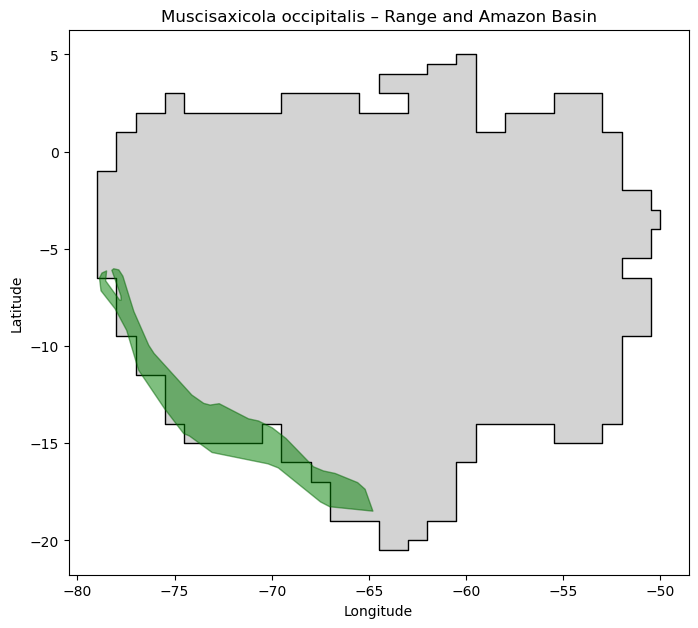

In [11]:
nbr_species_plot = 7
species_geom = results[nbr_species_plot ]["geometry"]
species_to_plot = results[nbr_species_plot ]["sci_name"]

fig, ax = plt.subplots(figsize=(8, 8))

# Amazon basin
gpd.GeoSeries(
    [amazon_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=1,
    label="Amazon basin"
)

# Species range
gpd.GeoSeries(
    [species_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="green",
    alpha=0.5,
    edgecolor="darkgreen",
    linewidth=1,
    label=species_to_plot
)

ax.set_title(f"{species_to_plot} – Range and Amazon Basin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.show()


In [ ]:
check_results_cluster = gpd.read_file(Path("data") / "filtered_species_3.gpkg")

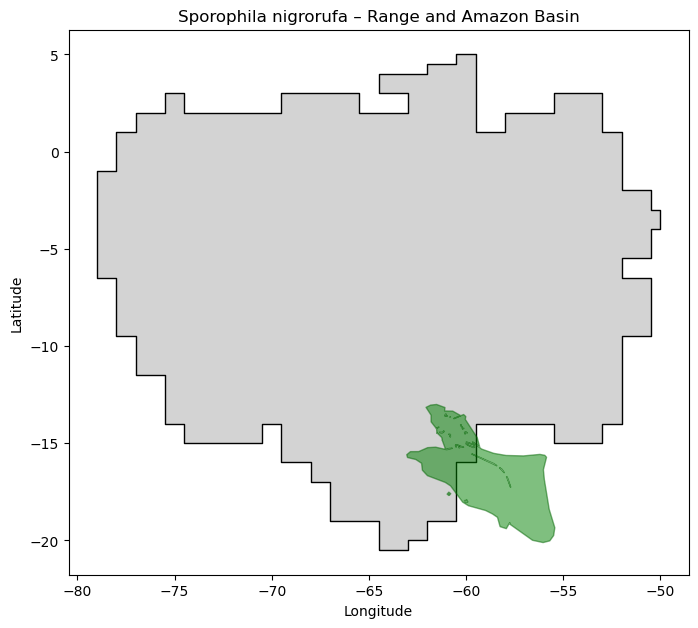

In [13]:
species_geom = check_results_cluster["geometry"][0]
species_to_plot = check_results_cluster["sci_name"][0]


fig, ax = plt.subplots(figsize=(8, 8))

# Amazon basin
gpd.GeoSeries(
    [amazon_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=1,
    label="Amazon basin"
)

# Species range
gpd.GeoSeries(
    [species_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="green",
    alpha=0.5,
    edgecolor="darkgreen",
    linewidth=1,
    label=species_to_plot
)

ax.set_title(f"{species_to_plot} – Range and Amazon Basin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.show()
